In [1]:
# ── SETUP ─────────────────────────────────────
import numpy as np               # cálculo numérico: arrays y operaciones vectorizadas
import pandas as pd              # tablas de datos (DataFrame), tipo hoja de Excel
import matplotlib.pyplot as plt  # dibujar gráficos

# De scikit-learn importamos solo lo que vamos a usar:
from sklearn.datasets import fetch_california_housing  # dataset de ejemplo (viviendas)
from sklearn.model_selection import train_test_split   # parte los datos en train/test
from sklearn.linear_model import LinearRegression      # el modelo de regresión lineal
from sklearn.preprocessing import PolynomialFeatures   # crea x², x³... (curvas)
from sklearn.pipeline import make_pipeline             # encadena pasos en un solo objeto
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # métricas

# Cargamos el dataset.
#   as_frame=True -> nos lo devuelve como DataFrame de pandas (más cómodo que arrays).
#   Se descarga 1 sola vez de internet y queda en caché local.
data = fetch_california_housing(as_frame=True)

# data.frame = la tabla completa (todas las variables + la columna objetivo).
df = data.frame

print("Filas, columnas:", df.shape)  # .shape -> (nº filas, nº columnas)
df.head()                            # .head() -> primeras 5 filas para echar un vistazo
 

Filas, columnas: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


('Pendiente (coeficiente):', np.float64(0.41793849201896294))
('Intercept:', np.float64(0.4508557670326787))


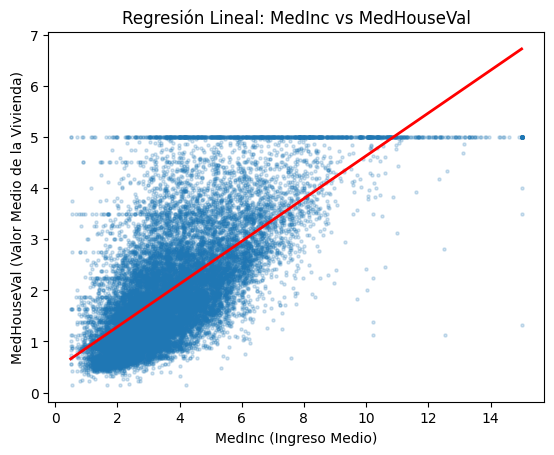

In [6]:

X = df[["MedInc"]]  # X = tabla con solo la columna "MedInc" (variable independiente)

Y = df["MedHouseVal"]  # Y = la columna "MedHouseVal" (variable dependiente, objetivo)

modelo = LinearRegression()  # creamos el modelo de regresión lineal

modelo.fit(X, Y)  # entrenamos el modelo con nuestros datos (X, Y)

print(("Pendiente (coeficiente):", modelo.coef_[0]))  # coeficiente de la recta
print(("Intercept:", modelo.intercept_))  # ordenada en el origen (dónde corta el eje Y)


# s -> tamaño de los puntos, alpha -> transparencia (0=transparente, 1=opaco)
plt.scatter(X, Y, s=5, alpha=0.2)  # dibuja los puntos (X, Y) con algo de transparencia


# El modelo espera un tabla con la misma columna que en el fit, así que le damos una tabla con la columna "MedInc" y 100 filas.
xs = np.linspace(X["MedInc"].min(), X["MedInc"].max(), 100)  # 100 puntos entre el mínimo y máximo de MedInc

x_line = pd.DataFrame({"MedInc": xs})  # tabla con la columna "MedInc" y los 100 puntos

plt.plot(xs, modelo.predict(x_line), color="red", linewidth=2)  # dibuja la línea de regresión (predicciones del modelo)
plt.xlabel("MedInc (Ingreso Medio)")  # etiqueta del eje X
plt.ylabel("MedHouseVal (Valor Medio de la Vivienda)")  # etiqueta del eje
plt.title("Regresión Lineal: MedInc vs MedHouseVal")  # título del gráfico
plt.show()  # muestra el gráfico


 

In [10]:
X = df[["MedInc"]]  # X = tabla con solo la columna "MedInc" (variable independiente)

Y = df["MedHouseVal"]  # Y = la columna "MedHouseVal" (variable dependiente, objetivo)

modelo = LinearRegression()  # creamos el modelo de regresión lineal

modelo.fit(X, Y)  # entrenamos el modelo con nuestros datos (X, Y)

y_pred = modelo.predict(X)  # predicciones del modelo para cada fila de X

mae = mean_absolute_error(Y, y_pred)  # error absoluto medio
mse = mean_squared_error(Y, y_pred)  # error cuadrático medio
rmse = np.sqrt(mse)  # raíz del error cuadrático medio (misma unidad que Y)
r2 = r2_score(Y, y_pred)  # R² (coeficiente de determinación)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)
 

MAE: 0.626259337911434
MSE: 0.7011311502929527
RMSE: 0.8373357452616917
R²: 0.4734474918071989


Ejercicio 2

('Pendiente (coeficiente):', np.float64(0.009684496397427503))
('Intercept:', np.float64(1.7911991658938495))


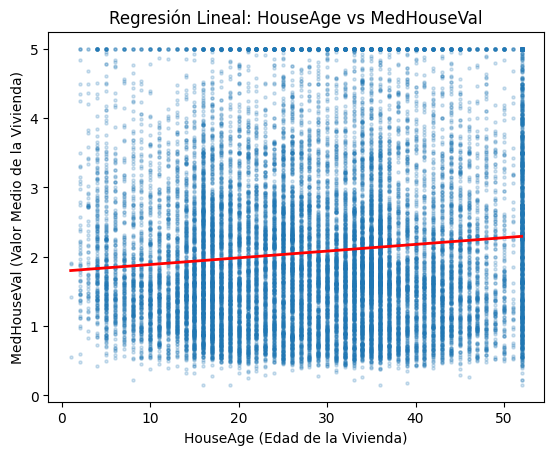

In [5]:
X = df[["HouseAge"]]  # X = tabla con solo la columna "HouseAge" (variable independiente)
Y = df["MedHouseVal"]  # Y = la columna "MedHouseVal" (variable dependiente, objetivo)


modelo = LinearRegression()  # creamos el modelo de regresión lineal
modelo.fit(X, Y)  # entrenamos el modelo con nuestros datos (X, Y)

print(("Pendiente (coeficiente):", modelo.coef_[0]))  # coeficiente de la recta
print(("Intercept:", modelo.intercept_))  # ordenada en el origen (dónde

# s -> tamaño de los puntos, alpha -> transparencia (0=transparente, 1=opaco)
plt.scatter(X, Y, s=5, alpha=0.2)  # dibuja los puntos (X, Y) con algo de transparencia


# El modelo espera un tabla con la misma columna que en el fit, así que le damos una tabla con la columna "HouseAge" y 100 filas.
xs = np.linspace(X["HouseAge"].min(), X["HouseAge"].max(), 100)  # 100 puntos entre el mínimo y máximo de HouseAge

x_line = pd.DataFrame({"HouseAge": xs})  # tabla con la columna "HouseAge" y los 100 puntos


plt.plot(xs, modelo.predict(x_line), color="red", linewidth=2)  # dibuja la línea de regresión (predicciones del modelo)
plt.xlabel("HouseAge (Edad de la Vivienda)")  # etiqueta del eje X
plt.ylabel("MedHouseVal (Valor Medio de la Vivienda)")  # etiqueta del eje Y
plt.title("Regresión Lineal: HouseAge vs MedHouseVal")  # título del gráfico
plt.show()  # muestra el gráfico
 

In [9]:
X = df[["HouseAge"]]  # X = tabla con solo la columna "HouseAge" (variable independiente)

Y = df["MedHouseVal"]  # Y = la columna "MedHouseVal" (variable dependiente, objetivo)

modelo = LinearRegression()  # creamos el modelo de regresión lineal

modelo.fit(X, Y)  # entrenamos el modelo con nuestros datos (X, Y)

y_pred = modelo.predict(X)  # predicciones del modelo para cada fila de X

mae = mean_absolute_error(Y, y_pred)  # error absoluto medio
mse = mean_squared_error(Y, y_pred)  # error cuadrático medio
rmse = np.sqrt(mse)  # raíz del error cuadrático medio (misma unidad que Y)
r2 = r2_score(Y, y_pred)  # R² (coeficiente de determinación)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)
 

MAE: 0.9062051122132927
MSE: 1.3166951184561144
RMSE: 1.1474733628525389
R²: 0.011156305266710742


Regresión Multiple

In [11]:
X = df.drop(columns=["MedHouseVal"])  # X = todas las columnas excepto "MedHouseVal"
Y = df["MedHouseVal"]  # Y = la columna "MedHouseVal" (variable dependiente, objetivo)
modelo = LinearRegression()  # creamos el modelo de regresión lineal
modelo.fit(X, Y)  # entrenamos el modelo con nuestros datos (X, Y


coeficientes = pd.Series(modelo.coef_, index=X.columns).sort_values(ascending=False)  # coeficientes del modelo con nombres de columnas
print(coeficientes)  # mostramos los coeficientes ordenados de mayor a menor
print()

print("R²:", r2_score(Y, modelo.predict(X)))  # R² del modelo con todas las variables

AveBedrms     0.645066
MedInc        0.436693
HouseAge      0.009436
Population   -0.000004
AveOccup     -0.003787
AveRooms     -0.107322
Latitude     -0.421314
Longitude    -0.434514
dtype: float64

R²: 0.606232685199805


Ejemplo con 3 variables: MedInc, HouseAge, AveRooms

In [ ]:
# ejemplo modelo regresion multilineal con 3 variables independientes (MedInc, HouseAge, AveRooms)
X = df[["MedInc", "HouseAge", "AveRooms"]]  # X = tabla con solo las columnas "MedInc", "HouseAge" y "AveRooms" (variables independientes)
Y = df["MedHouseVal"]  # Y = la columna "MedHouseVal" (variable dependiente, objetivo)
modelo = LinearRegression()  # creamos el modelo de regresión lineal 
modelo.fit(X, Y)  # entrenamos el modelo con nuestros datos (X, Y)
coeficientes = pd.Series(modelo.coef_, index=X.columns).sort_values(ascending=False) # coeficientes del modelo con nombres de columnas
print(coeficientes)  # mostramos los coeficientes ordenados de mayor a menor
print()
print("R²:", r2_score(Y, modelo.predict(X)))  # R² del modelo con solo 3 variables

MedInc      0.442763
HouseAge    0.016822
AveRooms   -0.027153
dtype: float64

R²: 0.5121018839958532


In [13]:
cols = ["MedInc", "HouseAge", "AveRooms"]

X3 = df[cols]  # X3 = tabla con solo las columnas de cols
y = df["MedHouseVal"]  # y = la columna "MedHouseVal" (variable dependiente, objetivo)
modelo3 = LinearRegression()  # creamos un nuevo modelo de regresión lineal
modelo3.fit(X3, Y)  # entrenamos el nuevo modelo con las columnas seleccion

print(pd.Series(modelo3.coef_, index=X3.columns).sort_values(ascending=False))  # coeficientes del nuevo modelo
print("R²:", r2_score(Y, modelo3.predict(X3)))  # R² del nuevo modelo con las columnas seleccionadas

MedInc      0.442763
HouseAge    0.016822
AveRooms   -0.027153
dtype: float64
R²: 0.5121018839958532


dividiendo los datos en train y test y modelo polinomial

In [14]:
X = df[["MedInc"]]

Y = df["MedHouseVal"]

# train_test_split -> divide los datos en 2 partes: una para entrenar el modelo (train) y otra para evaluarlo (test).
# test_size=0.2 -> el 20% de los datos se usan para test y el 80% para train.
# random_state=42 -> fija la semilla del generador de números aleatorios para que la división sea siempre la misma (reproducible).
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Entrenamos el modelo con los datos de train.
for grado in [1, 2, 5, 15]:
    # PolynomialFeatures(grado) -> crea nuevas columnas con x², x³... hasta el grado indicado.
    # make_pipeline -> encadena PolynomialFeatures y LinearRegression en un solo objeto.Primero transforma
    #  y luego ajusta la regresión lineal.
    modelo = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    modelo.fit(x_train, y_train)
   
    # medir el R² en train y test para cada grado
    r2_tr = r2_score(y_train, modelo.predict(x_train))
    r2_ts = r2_score(y_test, modelo.predict(x_test))

    # grado:>2 -> muestra el grado con al menos 2 dígitos (para que quede alineado)
    print(f"Grado {grado:>2}: R² train = {r2_tr:.4f}, R² test = {r2_ts:.4f}")
 

Grado  1: R² train = 0.4770, R² test = 0.4589
Grado  2: R² train = 0.4816, R² test = 0.4633
Grado  5: R² train = 0.4910, R² test = 0.4668
Grado 15: R² train = 0.3982, R² test = 0.3615


In [ ]:
# ejemplo 4, con más grados y sin el grado 15 que se ve muy mal
X = df[["MedInc"]]

Y = df["MedHouseVal"]

# train_test_split -> divide los datos en 2 partes: una para entrenar el modelo (train) y otra para evaluarlo (test).
# test_size=0.2 -> el 20% de los datos se usan para test y el 80% para train.
# random_state=42 -> fija la semilla del generador de números aleatorios para que la división sea siempre la misma (reproducible).
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Entrenamos el modelo con los datos de train.
for grado in [1, 2, 3, 4, 5, 6, 10]:
    # PolynomialFeatures(grado) -> crea nuevas columnas con x², x³... hasta el grado indicado.
    # make_pipeline -> encadena PolynomialFeatures y LinearRegression en un solo objeto.Primero transforma
    #  y luego ajusta la regresión lineal.
    modelo = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    modelo.fit(x_train, y_train)
   
    # medir el R² en train y test para cada grado
    r2_tr = r2_score(y_train, modelo.predict(x_train))
    r2_ts = r2_score(y_test, modelo.predict(x_test))

    # grado:>2 -> muestra el grado con al menos 2 dígitos (para que quede alineado)
    print(f"Grado {grado:>2}: R² train = {r2_tr:.4f}, R² test = {r2_ts:.4f}")

Grado  1: R² train = 0.4770, R² test = 0.4589
Grado  2: R² train = 0.4816, R² test = 0.4633
Grado  3: R² train = 0.4908, R² test = 0.4671
Grado  4: R² train = 0.4909, R² test = 0.4673
Grado  5: R² train = 0.4910, R² test = 0.4668
Grado  6: R² train = 0.4922, R² test = 0.4689
Grado 10: R² train = 0.4929, R² test = 0.4690


ejercico Nº 5

In [16]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)  # cargamos el dataset de diabetes como DataFrame

In [ ]:
# primeros registros del dataset de diabetes
diabetes.frame.head() # mostramos las primeras filas para echar un vistazo, contiene todos los datos (variables independientes) y la columna "target" (variable dependiente, objetivo)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [19]:
diabetes.frame.shape  # filas, columnas del dataset de diabetes

(442, 11)

In [24]:
X = diabetes.data  # X = todas las columnas de datos (variables independientes)
Y = diabetes.target  # Y = la columna "target" (variable dependiente, objetivo)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)  # dividimos en train/test

# vemos las priemeras filas de x_train para echar un vistazo
print(x_train.head())

# vemos las primeras filas de y_train para echar un vistazo
print(y_train.head())

          age       sex       bmi        bp        s1        s2        s3  \
17   0.070769  0.050680  0.012117  0.056301  0.034206  0.049416 -0.039719   
66  -0.009147  0.050680 -0.018062 -0.033213 -0.020832  0.012152 -0.072854   
137  0.005383 -0.044642  0.049840  0.097615 -0.015328 -0.016345 -0.006584   
245 -0.027310 -0.044642 -0.035307 -0.029770 -0.056607 -0.058620  0.030232   
31  -0.023677 -0.044642 -0.065486 -0.081413 -0.038720 -0.053610  0.059685   

           s4        s5        s6  
17   0.034309  0.027364 -0.001078  
66   0.071210  0.000272  0.019633  
137 -0.002592  0.017036 -0.013504  
245 -0.039493 -0.049872 -0.129483  
31  -0.076395 -0.037129 -0.042499  
17     144.0
66     150.0
137    280.0
245    125.0
31      59.0
Name: target, dtype: float64


In [29]:
modelo = LinearRegression()  # creamos el modelo de regresión lineal
modelo.fit(x_train, y_train)  # entrenamos el modelo con los datos de train
pred = modelo.predict(x_test)  # predicciones del modelo para los datos de test
coefficients = pd.Series(modelo.coef_, index=X.columns).sort_values(ascending=False)  # coeficientes del modelo con nombres de columnas
print(coefficients)  # mostramos los coeficientes ordenados de mayor a menor
print("MAE: ", mean_absolute_error(y_test, pred))  # MAE del modelo con los datos de test
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))  # RMSE del modelo con los datos de test
print("R²: ", r2_score(y_test, pred))  # R² del modelo con los datos de test

# paciente_nuevo = una tabla con una fila y las mismas columnas que X, con los valores promedio de cada columna
paciente_nuevo = X.mean().to_frame().T  
print("Paciente nuevo (valores promedio):")
print(modelo.predict(paciente_nuevo)[0])

s5     736.198859
bmi    542.428759
s2     518.062277
bp     347.703844
s4     275.317902
s3     163.419983
s6      48.670657
age     37.904021
sex   -241.964362
s1    -931.488846
dtype: float64
MAE:  42.79409467959994
RMSE: 53.85344583676592
R²:  0.4526027629719197
Paciente nuevo (valores promedio):
151.3456045398599


In [30]:
from sklearn.datasets import load_diabetes

diab = load_diabetes(as_frame=True)  # cargamos el dataset de diabetes como DataFrame
dfd = diab.frame  # dfd = diabetes frame (la tabla completa del dataset de diabetes)
print("Filas, columnas:", dfd.shape)  # número de filas y columnas del dataset de diabetes
dfd.head()  # primeras 5 filas del dataset de diabetes para echar un vistazo
 

Filas, columnas: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [31]:
X = dfd.drop(columns=["target"])  # X = todas las columnas excepto "target"
Y = dfd["target"]  # Y = la columna "target" (variable dependiente, objetivo)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

modelo = LinearRegression()  # creamos el modelo de regresión lineal
modelo.fit(X_train, Y_train)  # entrenamos el modelo con los datos de train

pred = modelo.predict(X_test)  # predicciones del modelo para los datos de test

print("MAE :", mean_absolute_error(Y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, pred)))
print("R²  :", r2_score(Y_test, pred))

# paciente_nuevo = una tabla con una fila y las mismas columnas que X, con los valores promedio de cada columna
paciente_nuevo = X.mean().to_frame().T  
print("Paciente nuevo (valores promedio):")
print(modelo.predict(paciente_nuevo)[0])  # predicción del modelo para el paciente nuevo (valor de target)

MAE : 42.79409467959994
RMSE: 53.85344583676592
R²  : 0.4526027629719197
Paciente nuevo (valores promedio):
151.3456045398599


Ejercicio Nº 6

In [32]:
rng = np.random.default_rng(42)   # semilla -> mismos datos siempre
n = 500
antiguedad = rng.integers(0, 20, n)         # años del coche
kms        = rng.integers(0, 250_000, n)    # kilómetros recorridos
potencia   = rng.integers(70, 300, n)       # caballos (CV)

# Precio "real": baja con antigüedad y km, sube con potencia, + algo de ruido aleatorio
precio = 35000 - 1200*antiguedad - 0.05*kms + 60*potencia + rng.normal(0, 2000, n)
precio = precio.clip(1000).round(0)          # nada de precios negativos

coches = pd.DataFrame({"antiguedad": antiguedad, "kms": kms,
                       "potencia": potencia, "precio": precio})
print("Filas, columnas:", coches.shape)
coches.head()

Filas, columnas: (500, 4)


,antiguedad,kms,potencia,precio
0,1,28432,255,47486.0
1,15,162982,239,25447.0
2,13,240653,198,14686.0
3,8,216872,273,27943.0
4,8,68519,99,26068.0


In [37]:
X = coches.drop(columns=["precio"])  # X = todas las columnas excepto "precio"
Y = coches["precio"]  # Y = la columna "precio" (variable dependiente, objetivo)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

modelo = LinearRegression()  # creamos el modelo de regresión lineal
modelo.fit(x_train, y_train)  # entrenamos el modelo con los datos de train

pred = modelo.predict(x_test)  # predicciones del modelo para los datos de test

coefficients = pd.Series(modelo.coef_, index=X.columns).sort_values(ascending=False)  # coeficientes del modelo con nombres de columnas
print(coefficients)  # mostramos los coeficientes ordenados de mayor a menor    

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²  :", r2_score(y_test, pred))

# coche_nuevo = una tabla con una fila y las mismas columnas que X, con los valores promedio de cada columna
coche_nuevo = X.mean().to_frame().T  
print("Coche nuevo (valores promedio):")
print(modelo.predict(coche_nuevo)[0]) 

potencia        61.257253
kms             -0.050174
antiguedad   -1174.865486
dtype: float64
MAE : 1638.2317308255356
RMSE: 2158.589366467412
R²  : 0.942652643630642
Coche nuevo (valores promedio):
28526.08049641727


In [38]:
X = coches.drop(columns=["precio"])  # X = todas las columnas excepto "precio"
Y = coches["precio"]  # Y = la columna "precio" (variable dependiente, objetivo)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

modelo = LinearRegression()  # creamos el modelo de regresión lineal
modelo.fit(X_train, Y_train)  # entrenamos el modelo con los datos de train

pred = modelo.predict(X_test)  # predicciones del modelo para los datos de test

print("MAE :", mean_absolute_error(Y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, pred)))
print("R²  :", r2_score(Y_test, pred))

print(pd.Series(modelo.coef_, index=X.columns))

coche_nuevo = pd.DataFrame({"antiguedad": [5], "kms": [100_000], "potencia": [150]})
print("Precio estimado para el coche nuevo:", modelo.predict(coche_nuevo)[0])

MAE : 1638.2317308255356
RMSE: 2158.589366467412
R²  : 0.942652643630642
antiguedad   -1174.865486
kms             -0.050174
potencia        61.257253
dtype: float64
Precio estimado para el coche nuevo: 32891.566890967166


| Modelo | Qué añade | Dónde es mejor |
|---|---|---|
| **LinearRegression** | nada (OLS puro) | caso base, pocas variables, muchos datos |
| **Ridge** | penaliza coeficientes grandes (**L2**) | multicolinealidad, evitar overfitting |
| **Lasso** | penaliza (**L1**) y pone coeficientes a **0** | selección automática de variables |
| **ElasticNet** | mezcla L1 + L2 | lo mejor de Ridge y Lasso |
| **SGDRegressor** | ajuste por descenso de gradiente | datasets enormes (millones de filas) |
| **Huber / RANSAC / TheilSen** | robustos a **outliers** | datos con valores atípicos |
| **BayesianRidge** | versión bayesiana | quieres incertidumbre en la predicción |

Cierra

Clasificación --> etiquetas

Regresión -> números

En ambos casos con sciki-learn
 

Más allá de LinearRegressión.

LinearRegression es solo el caso base (minimos cuadrados). Hay más modelos, todos comparten la misma API (.fit/.predict) y dibujan una recta/plano, lo que cambia es lo que optimizan: